<center>

$\Huge \textbf{Universidad Nacional Autónoma de México}$  
$\Huge \textbf{Facultad de Ciencias}$  
<p align="center">
  <img src="https://www.icat.unam.mx/wp-content/uploads/2021/11/Copia-de-LogoUNAM.-Azul.-Fondo-transparente.png" alt="UNAM" width="200"/>
</p>

<hr style="height:3px; background-color:#0B6E4F; border:none;"/>


$\LARGE \textbf{Inteligencia Artificial}$  

$\Large \textit{Laboratorio 4.2 Clase}$  


\begin{array}{rl}
\textbf{Docente:} & Dra. Jessica Sarahi Méndez Rincón \\[6pt]
\textbf{Ayudante de laboratorio:} & Diego Eduardo Peña Villegas \\[6pt]
\textbf{Alumno:} & Isaac Giovani Escobar Gonzalez \\[6pt]
\textbf{Fecha de realización:} & 13/04/2026
\end{array}

</center>

In [ ]:
import numpy as np

# Regresión lineal y logaritmica

In [ ]:
class RegresionLineal:
    def __init__(self, alpha=0.01, iteraciones=1000):
        self.alpha = alpha
        self.iteraciones = iteraciones
        self.w = None
        self.b = None

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)
        self.b = 0

        for _ in range(self.iteraciones):
            # Predicción lineal
            y_pred = np.dot(X, self.w) + self.b

            # Cálculo de gradientes
            dw = (1 / n_samples) * np.dot(X.T, (y_pred - y))
            db = (1 / n_samples) * np.sum(y_pred - y)

            # Actualización
            self.w -= self.alpha * dw
            self.b -= self.alpha * db

    def predict(self, X):
        return np.dot(X, self.w) + self.b

In [ ]:
class RegresionLogistica:
    def __init__(self, alpha=0.01, iteraciones=1000):
        self.alpha = alpha
        self.iteraciones = iteraciones

        self.w = None
        self.b = None

    def _sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        n_samples, n_features = X.shape
        #1. Inicializar theta (ceros) y m_features asegurda que
        #tengamos un peso para cada variable
        self.w = np.zeros(n_features)
        self.b = 0

        for _ in range(self.iteraciones):
            #2a. Calcular producto lineal es la base de la regresión
            modelo_lineal = np.dot(X, self.w) + self.b
            # aplicar Sigmoide, probabilidad entre 0 y 1
            y_pred = self._sigmoid(modelo_lineal)
            # Calcula el error con y_pred -y
            # calcular el gradiante dw y db
            dw = (1 / n_samples) * np.dot(X.T, (y_pred - y))
            db = (1 / n_samples) * np.sum(y_pred - y)

            #Actualizar parámetros
            self.w -= self.alpha * dw
            self.b -= self.alpha * db

    def predict(self, X):
        modelo_lineal = np.dot(X, self.w) + self.b
        y_pred = self._sigmoid(modelo_lineal)
        #Retorna el umbral de decisión (threshold)
        #Por defecto usamos 0.5:
        # Si la probabilidad es > 0.5 -> Clase 1 (Aprobado).
        # Si la probabilidad es <= 0.5 -> Clase 0 (Reprobado).
        return [1 if i > 0.5 else 0 for i in y_pred]

Aplicandolo:

Resultado para 5.5 horas: Aprobado


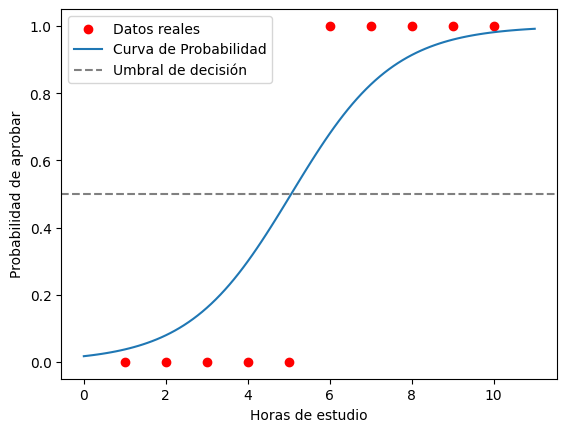

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. PREPARACIÓN DE DATOS (Simulando una clase real) ---
# Horas de estudio de 10 alumnos
X = np.array([[1], [2], [3], [4], [5], [6], [7], [8], [9], [10]])
# 0 = Reprobado, 1 = Aprobado
y = np.array([0, 0, 0, 0, 0, 1, 1, 1, 1, 1])

# --- 2. EL MODELO (Usando la lógica que desarrollamos antes) ---
modelo = RegresionLogistica(alpha=0.1, iteraciones=500)
modelo.fit(X, y)

# --- 3. PREDICCIÓN APLICADA ---
# ¿Qué pasa con un alumno que estudia 5.5 horas?
horas_nuevas = np.array([[5.5]])
prediccion = modelo.predict(horas_nuevas)

resultado = "Aprobado" if prediccion[0] == 1 else "Reprobado"
print(f"Resultado para 5.5 horas: {resultado}")

# --- 4. VISUALIZACIÓN (Crucial en experimentación) ---
plt.scatter(X, y, color='red', label='Datos reales')
# Generamos puntos para ver la curva sigmoide
X_curva = np.linspace(0, 11, 100).reshape(-1, 1)
z = np.dot(X_curva, modelo.w) + modelo.b
probabilidades = 1 / (1 + np.exp(-z))

plt.plot(X_curva, probabilidades, label='Curva de Probabilidad')
plt.axhline(y=0.5, color='gray', linestyle='--', label='Umbral de decisión')
plt.xlabel("Horas de estudio")
plt.ylabel("Probabilidad de aprobar")
plt.legend()
plt.show()

# SVM

In [ ]:
import numpy as np
from sklearn.svm import SVC # La versión profesional

class SVM_Manual:
    def __init__(self, learning_rate=0.001, lambda_param=0.01, n_iters=1000):
        self.lr = learning_rate
        self.lambda_param = lambda_param
        self.n_iters = n_iters
        self.w = None
        self.b = None

    def fit(self, X, y):
        # Convertir etiquetas a [-1, 1] si vienen como [0, 1]
        y_ = np.where(y <= 0, -1, 1)
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)
        self.b = 0

        for _ in range(self.n_iters):
            for idx, x_i in enumerate(X):
                # Condición de la pérdida Hinge
                condition = y_[idx] * (np.dot(x_i, self.w) - self.b) >= 1
                if condition:
                    self.w -= self.lr * (2 * self.lambda_param * self.w)
                else:
                    self.w -= self.lr * (2 * self.lambda_param * self.w
                                         - np.dot(x_i, y_[idx]))
                    self.b -= self.lr * y_[idx]

    def predict(self, X):
        approx = np.dot(X, self.w) - self.b
        return np.sign(approx)

Para probar la implementación manual de SVM, se necesita generar datos sintéticos que sepamos que son "separables" para verificar si el algoritmo encuentra los pesos correctos.

Pesos finales (w): [0.58977016 0.17946483]
Sesgo final (b): -0.1520000000000001


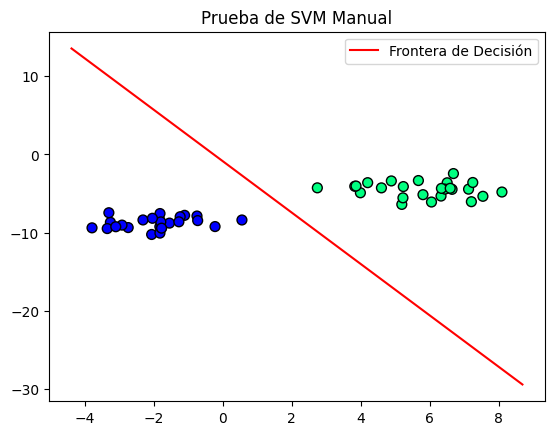

In [ ]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# 1. Generamos datos de prueba (2 grupos de puntos)
# Usamos etiquetas -1 y 1 porque así lo definimos en el algoritmo manual
X, y = make_blobs(n_samples=50, n_features=2, centers=2, cluster_std=1.05, random_state=40)
y = np.where(y == 0, -1, 1)

# 2. Instanciamos y entrenamos el modelo manual
modelo_svm = SVM_Manual(learning_rate=0.001, lambda_param=0.01, n_iters=1000)
modelo_svm.fit(X, y)

print(f"Pesos finales (w): {modelo_svm.w}")
print(f"Sesgo final (b): {modelo_svm.b}")

# 3. Función para visualizar el resultado
def visualizar_svm(X, y, model):
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='winter', s=50, edgecolors='k')
    ax = plt.gca()
    xlim = ax.get_xlim()

    # Calculamos la línea de decisión: w1*x1 + w2*x2 - b = 0
    # Despejando x2: x2 = (-w1*x1 + b) / w2
    x1 = np.linspace(xlim[0], xlim[1], 100)
    x2 = (model.b - model.w[0] * x1) / model.w[1]

    plt.plot(x1, x2, 'r-', label="Frontera de Decisión")
    plt.title("Prueba de SVM Manual")
    plt.legend()
    plt.show()

visualizar_svm(X, y, modelo_svm)

Análisis de los Resultados
 1. Separación Lineal: La línea roja (tu frontera de decisión) ha logrado separar perfectamente el grupo azul del grupo verde. Esto indica que el hiperplano encontrado es válido.

 2. Los Pesos ($w$): Tus pesos finales $[0.5897, 0.1794]$ no son cero, lo que significa que el algoritmo actualizó los parámetros mediante el gradiente de forma efectiva.

 3. El Sesgo ($b$): El valor de $-0.152$ es el que desplaza la línea fuera del origen $(0,0)$ para que pueda quedar justo en medio de las dos "nubes" de puntos.

 4. Optimización del Margen: Nota que la línea no está "pegada" a un grupo, sino que intenta mantener una distancia prudente de ambos. Eso es exactamente lo que busca una SVM: maximizar el margen.

<hr/>
<footer style="text-align:center; font-size:12px; color:gray;">
© 2026 UNAM Facultado de Ciencias – Todos los derechos reservados

</footer>